In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
results = pd.read_csv('./evaluation_results/eval_results_2025-11-17_01-17-51.csv')
results


,question,datetime,model_name,ground_truth,model_output,chunk_retrieval_time,generation_time,bleu,rouge,precision,recall,F1,recall@k,precision@k
0,What is the main goal for the NEREUS project,2025-11-17 01:07:39.372750,qwen3:4b,The goal of this report is to summarize eviden...,"Based on the uploaded document context, the ma...",0.011999,26.356647,0.014164,0.163743,tensor([0.8223]),tensor([0.8563]),tensor([0.8390]),1.0,1.0
1,Which substances in the Leopoldkanaal water ex...,2025-11-17 01:08:29.060585,qwen3:4b,While the water of the Leopoldkanaal showed to...,"Based on the uploaded document context, the su...",0.011999,46.255463,0.056973,0.239631,tensor([0.8346]),tensor([0.9008]),tensor([0.8664]),1.0,0.8
2,What is the main goal for the NEREUS project,2025-11-17 01:09:04.666043,qwen3:4b,The goal of this report is to summarize eviden...,"Based on the uploaded document context, the ma...",0.015974,33.637019,0.014164,0.163743,tensor([0.8229]),tensor([0.8566]),tensor([0.8394]),1.0,1.0
3,Which techniques were used in the GO-Fresh fie...,2025-11-17 01:09:56.758097,qwen3:4b,Three techniques: (1) Kreekrug Infiltratie Sys...,"Based on the uploaded document context, the sp...",0.020000,48.824324,0.006013,0.041379,tensor([0.7924]),tensor([0.7957]),tensor([0.7941]),1.0,0.2
4,What was the purpose of the trials conducted a...,2025-11-17 01:11:01.734560,qwen3:4b,The purpose of the trials at Dow Terneuzen wit...,"Based on the uploaded document context, the pu...",0.022619,60.157252,0.042279,0.192593,tensor([0.8206]),tensor([0.9170]),tensor([0.8661]),1.0,0.8
5,What pre-treatment steps were applied before N...,2025-11-17 01:12:22.190186,qwen3:4b,"Coagulation, flocculation, lamella seperation,...","Based on the uploaded document context, the sp...",0.026835,76.259012,0.002680,0.008130,tensor([0.7879]),tensor([0.8227]),tensor([0.8049]),0.0,0.0
6,What was the purpose of the trials conducted a...,2025-11-17 01:14:32.839256,qwen3:4b,The purpose of the trials at Dow Terneuzen wit...,"Based on the uploaded document context, the pu...",0.028034,126.424400,0.090709,0.175896,tensor([0.8159]),tensor([0.9104]),tensor([0.8605]),1.0,0.8
7,Which techniques were used in the GO-Fresh fie...,2025-11-17 01:15:43.570152,qwen3:4b,Three techniques: (1) Kreekrug Infiltratie Sys...,Based on the uploaded document context provide...,0.015511,67.542384,0.007875,0.054475,tensor([0.8013]),tensor([0.8029]),tensor([0.8021]),1.0,0.2
8,What are the costs for storing desalinated wat...,2025-11-17 01:16:52.321873,qwen3:4b,The construction of a water basin for storing ...,Based on the uploaded document context provide...,0.022587,65.585763,0.047584,0.105769,tensor([0.8158]),tensor([0.8662]),tensor([0.8402]),1.0,0.8
9,What are the costs for storing desalinated wat...,2025-11-17 01:17:51.729194,qwen3:4b,The construction of a water basin for storing ...,Based on the uploaded document context provide...,0.025731,55.816235,0.047584,0.105769,tensor([0.8157]),tensor([0.8671]),tensor([0.8406]),1.0,0.8


In [28]:
import json

evaluation_questions_and_answers = json.loads(open("questions_answers.json", "r", encoding="utf-8").read())
prepared_qa = []

for qa_pair in evaluation_questions_and_answers:
    prepared_qa.append({
        "question": qa_pair["question"]["nl"],
        "ground_truth": qa_pair["ground_truth"]["nl"],
        "project": qa_pair["project"],
        "language": "nl",
        "filename": qa_pair["filename"],
        "specificity": qa_pair["specificity"],
        "original_language": qa_pair["original_language"]
    })
    prepared_qa.append({
        "question": qa_pair["question"]["en"],
        "ground_truth": qa_pair["ground_truth"]["en"],
        "project": qa_pair["project"],
        "language": "en",
        "filename": qa_pair["filename"],
        "specificity": qa_pair["specificity"],
        "original_language": qa_pair["original_language"]
    })

for i, row in results.iterrows():
    question = row["question"]
    
    matches = next((item for item in prepared_qa if item["question"] == question), None)
    if matches:
        results.at[i, "original_language"] = matches["original_language"]
    else:
        print(f"No match found for question: {question}")

No match found for question: What pre-treatment steps were applied before NF/EDR to limit fouling?


In [29]:
english_metrics = results[results['original_language'] == 'english'].mean(numeric_only=True)
dutch_metrics = results[results['original_language'] == 'dutch'].mean(numeric_only=True)

for english, dutch in zip(english_metrics, dutch_metrics):
  print(f"english: {english} | dutch: {dutch}")

english: 0.0181249618530273 | dutch: 0.020957171916961625
english: 58.566156244277956 | dutch: 59.4421763420105
english: 0.04365810596465432 | dutch: 0.0272639828367709
english: 0.18712101491747885 | dutch: 0.07684812001362377
english: 1.0 | dutch: 1.0
english: 0.8799999999999999 | dutch: 0.5


In [30]:
for i, row in results.iterrows():
  print(f'qa pair {i}:')
  print('question:')
  print(row['question'])
  print()
  print('ground truth:')
  print(row['ground_truth'])
  print()
  print('generated output:')
  print(row['model_output'])
  print('________________________________________________________________________________________________________________________________________________________')

qa pair 0:
question:
What is the main goal for the NEREUS project

ground truth:
The goal of this report is to summarize evidence and experiences gathered during the project on the topic of social acceptance, i.e. the resource may be recovered and ready for reuse, but how does the end user feel about using them, knowing where they originated? 

generated output:
Based on the uploaded document context, the main goal for the NEREUS project is "recovering valuable resources from domestic wastewater." 

This is explicitly stated in the document: "The NEREUS (New Energy and Resources from Urban Sanitation) Project is an Interreg 2 Seas project with a consortium of 8 project partners across the United Kingdom, the Netherlands, Belgium, and France, working on the goal of recovering valuable resources from domestic wastewater."

The document also explains that the project was born from global pressures including freshwater and finite resources scarcity, as well as the desire to increase wastew

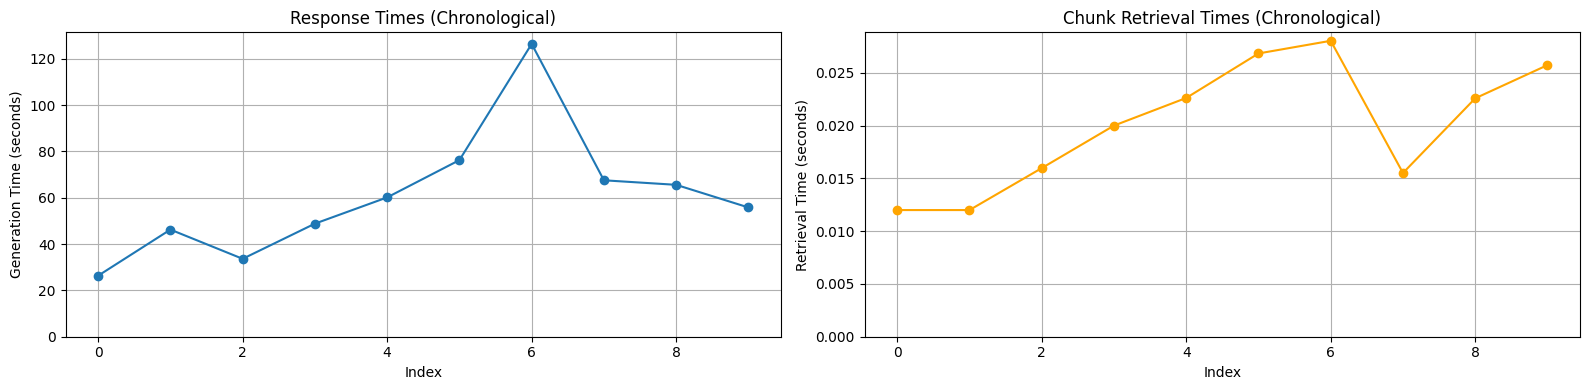

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)

axes[0].plot(results.index, results['generation_time'], marker='o', label='Generation Time')
axes[0].set_title('Response Times (Chronological)')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Generation Time (seconds)')
axes[0].set_ylim(0)
axes[0].grid(True)

axes[1].plot(results.index, results['chunk_retrieval_time'], marker='o', color='orange', label='Retrieval Time')
axes[1].set_title('Chunk Retrieval Times (Chronological)')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Retrieval Time (seconds)')
axes[1].set_ylim(0)
axes[1].grid(True)

plt.tight_layout()
plt.show()

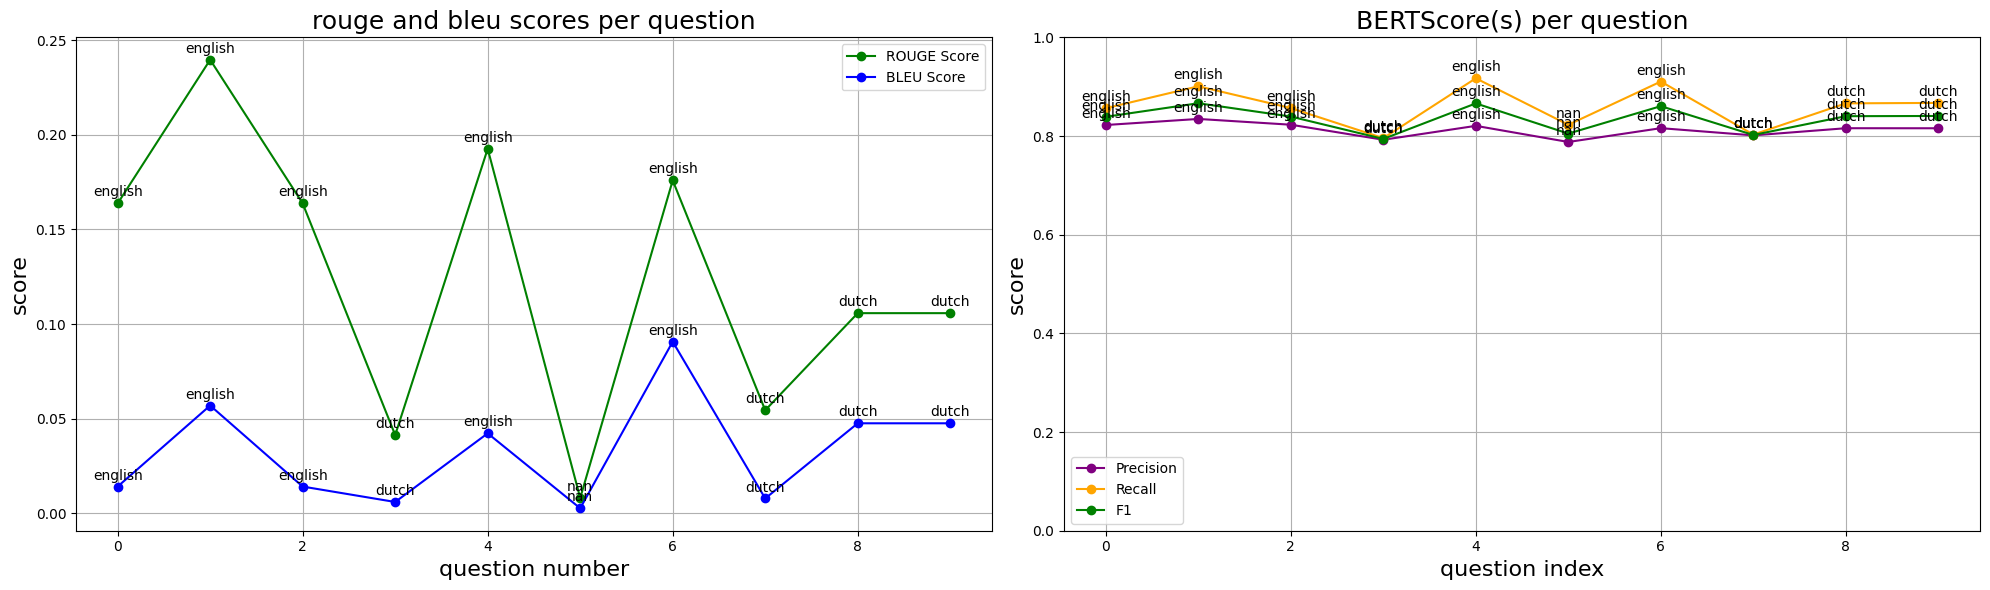

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].plot(results.index, results['rouge'], marker='o', label='ROUGE Score', color='green')
axes[0].plot(results.index, results['bleu'], marker='o', label='BLEU Score', color='blue')
axes[0].set_title('rouge and bleu scores per question', fontsize=18)
axes[0].set_xlabel('question number', fontsize=16)
axes[0].set_ylabel('score', fontsize=16)
axes[0].legend()
axes[0].grid(True)

# Add text above each point for the first plot
for i, txt in enumerate(results['original_language']):
  axes[0].annotate(txt, (results.index[i], results['rouge'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[0].annotate(txt, (results.index[i], results['bleu'][i]), textcoords="offset points", xytext=(0, 5), ha='center')

results['precision'] = results['precision'].apply(lambda x: float(str(x).strip("tensor([])")))
results['recall'] = results['recall'].apply(lambda x: float(str(x).strip("tensor([])")))
results['F1'] = results['F1'].apply(lambda x: float(str(x).strip("tensor([])")))
axes[1].plot(results.index, results['precision'], marker='o', label='Precision', color='purple')
axes[1].plot(results.index, results['recall'], marker='o', label='Recall', color='orange')
axes[1].plot(results.index, results['F1'], marker='o', label='F1', color='green')
axes[1].set_title('BERTScore(s) per question', fontsize=18)
axes[1].set_xlabel('question index', fontsize=16)
axes[1].set_ylabel('score', fontsize=16)
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 1)

# Add text above each point for the second plot
for i, txt in enumerate(results['original_language']):
  axes[1].annotate(txt, (results.index[i], results['precision'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[1].annotate(txt, (results.index[i], results['recall'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[1].annotate(txt, (results.index[i], results['F1'][i]), textcoords="offset points", xytext=(0, 5), ha='center')

plt.tight_layout()
plt.show()

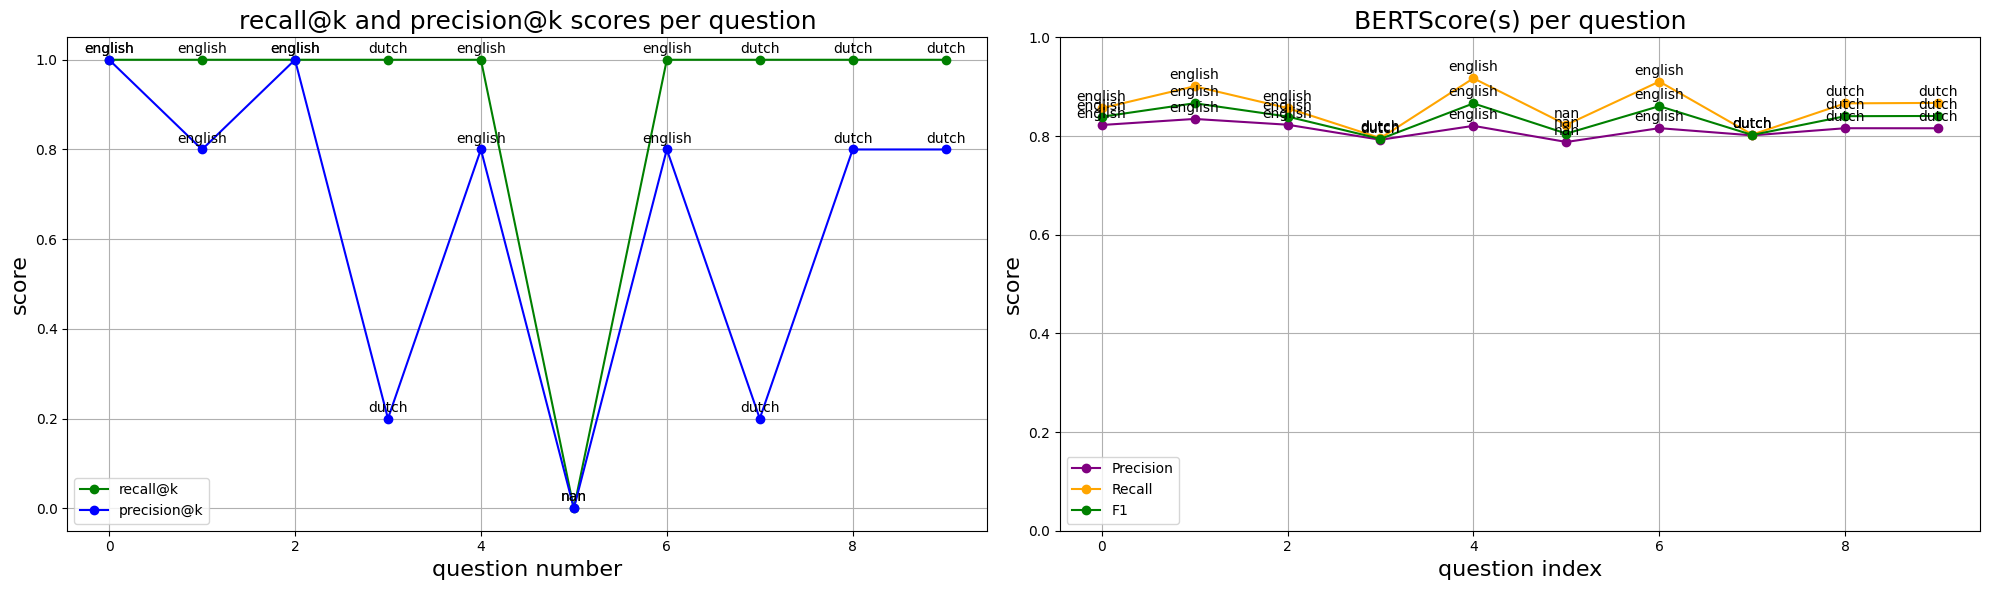

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].plot(results.index, results['recall@k'], marker='o', label='recall@k', color='green')
axes[0].plot(results.index, results['precision@k'], marker='o', label='precision@k', color='blue')
axes[0].set_title('recall@k and precision@k scores per question', fontsize=18)
axes[0].set_xlabel('question number', fontsize=16)
axes[0].set_ylabel('score', fontsize=16)
axes[0].legend()
axes[0].grid(True)

# Add text above each point for the first plot
for i, txt in enumerate(results['original_language']):
  axes[0].annotate(txt, (results.index[i], results['recall@k'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[0].annotate(txt, (results.index[i], results['precision@k'][i]), textcoords="offset points", xytext=(0, 5), ha='center')

results['precision'] = results['precision'].apply(lambda x: float(str(x).strip("tensor([])")))
results['recall'] = results['recall'].apply(lambda x: float(str(x).strip("tensor([])")))
results['F1'] = results['F1'].apply(lambda x: float(str(x).strip("tensor([])")))
axes[1].plot(results.index, results['precision'], marker='o', label='Precision', color='purple')
axes[1].plot(results.index, results['recall'], marker='o', label='Recall', color='orange')
axes[1].plot(results.index, results['F1'], marker='o', label='F1', color='green')
axes[1].set_title('BERTScore(s) per question', fontsize=18)
axes[1].set_xlabel('question index', fontsize=16)
axes[1].set_ylabel('score', fontsize=16)
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 1)

# Add text above each point for the second plot
for i, txt in enumerate(results['original_language']):
  axes[1].annotate(txt, (results.index[i], results['precision'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[1].annotate(txt, (results.index[i], results['recall'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[1].annotate(txt, (results.index[i], results['F1'][i]), textcoords="offset points", xytext=(0, 5), ha='center')

plt.tight_layout()
plt.show()

In [34]:
averages = results.mean(numeric_only=True)
print(averages)

chunk_retrieval_time     0.020129
generation_time         60.685850
bleu                     0.033003
rouge                    0.125113
precision                0.812940
recall                   0.859570
F1                       0.835330
recall@k                 0.900000
precision@k              0.640000
dtype: float64


first prompt:

chunk_retrieval_time     0.020129 -> 0.023403

generation_time         60.685850 -> 76.223767

bleu                     0.033003 -> 0.128261

rouge                    0.125113 -> 0.222738

precision                0.812940 -> 0.833550

recall                   0.859570 -> 0.862730

recall@k                 0.900000 -> 0.80000

precision@k              0.640000 -> 0.46000

dtype: float64

5 chunks retrieved using english query

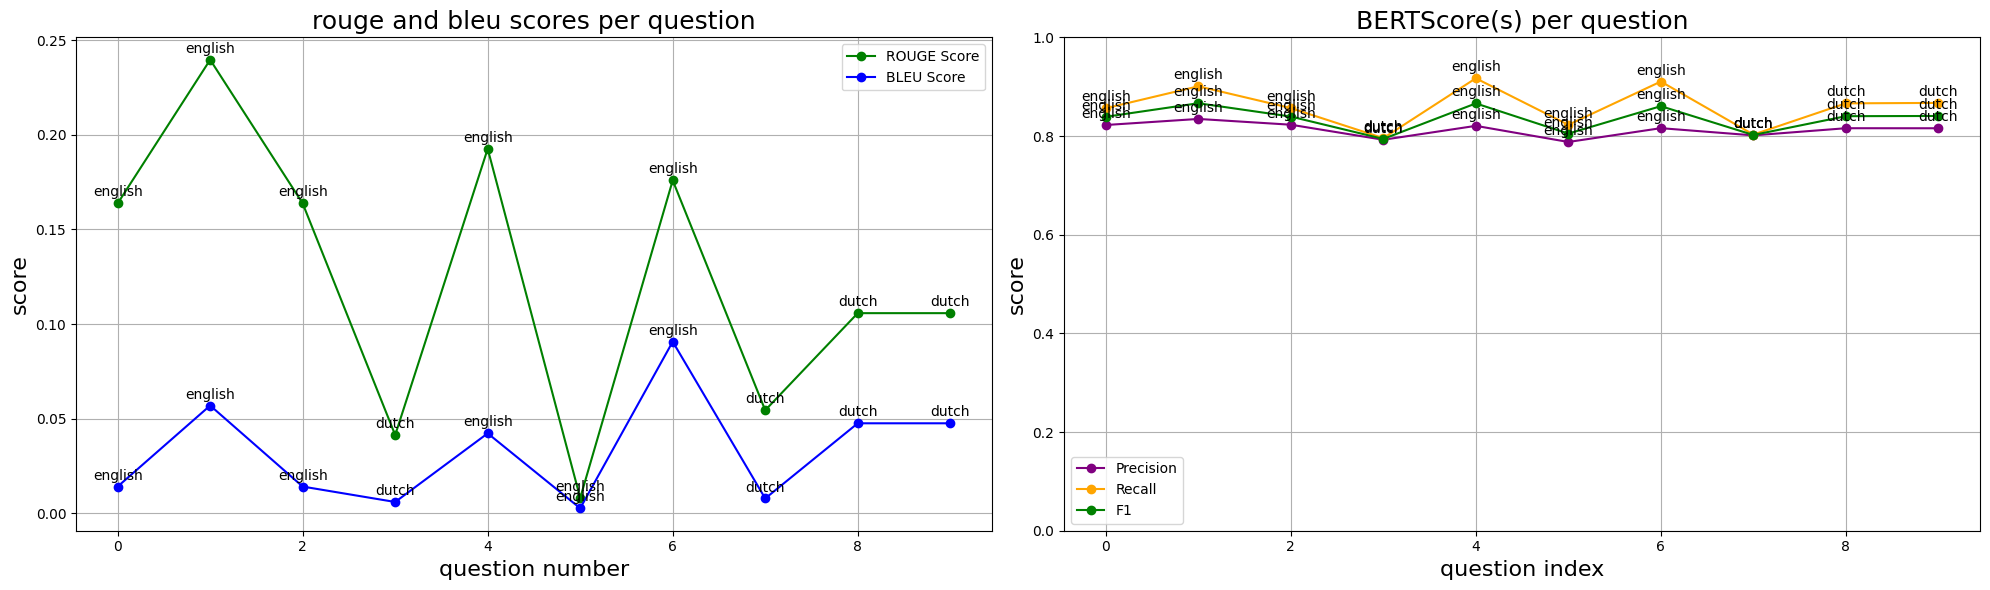


3 chunks retrieved using english query, and 3 chunks retrieved using translated dutch alternative

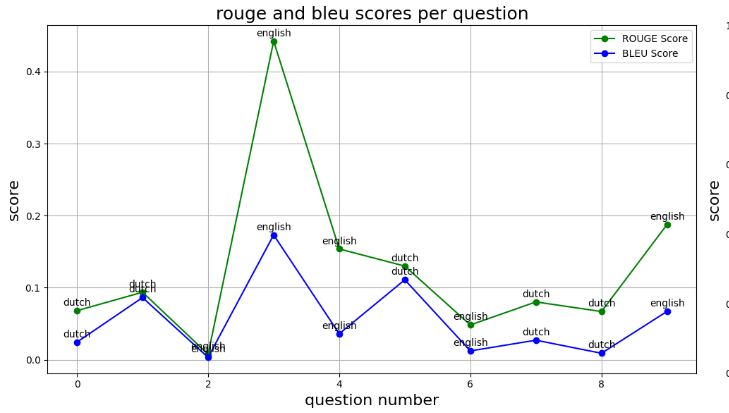

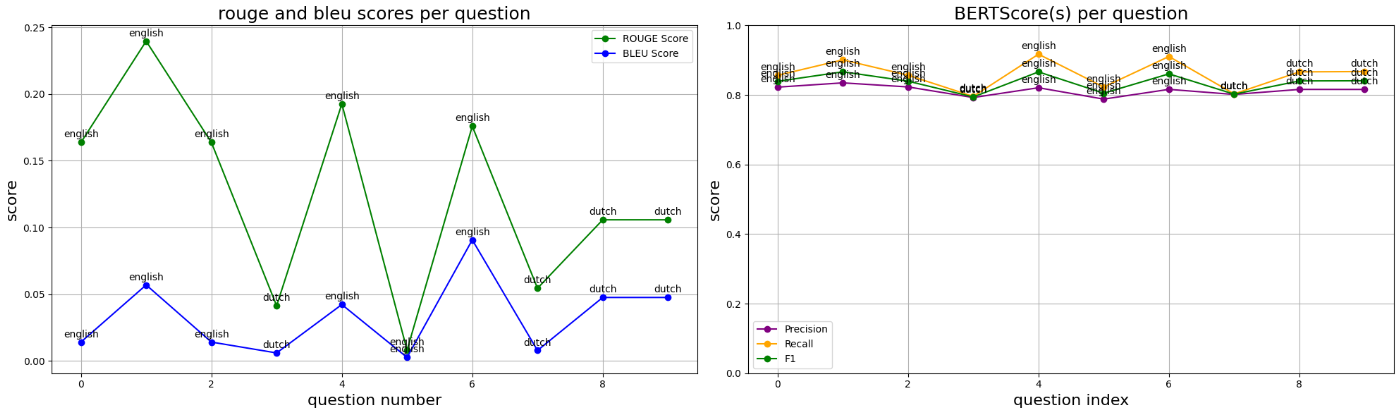